# 02 — Data Cleaning & Pipeline
## PurpleAir QC → LRAPA Correction → Three-way Merge → Save

Steps in this notebook:
1. A/B channel quality control on PurpleAir sensors
2. Apply LRAPA correction to raw CF=1 readings
3. Validate PurpleAir (corrected) against LRAPA regulatory monitors
4. Clean NOAA weather data
5. Aggregate 57 sensors → single hourly mean per timestamp
6. Inner-join all three datasets on timestamp
7. Add engineered features (wind components, rolling, lag)
8. Save analysis-ready dataset to `data/processed/`

In [1]:
import sys, pathlib
sys.path.append("../src")

from data_loader import PurpleAirLoader, NOAALoader, LRAPALoader
from preprocessing import (DataCleaner, TimeAligner, DataMerger,
                           aggregate_purpleair_sensors,
                           create_full_analysis_dataset)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

pathlib.Path("../data/processed").mkdir(exist_ok=True)

## 1. Load Raw Data

In [2]:
pa_raw    = PurpleAirLoader("../data/raw/purpleair").load_all_sensors_in_directory()
noaa_raw  = NOAALoader("../data/raw/noaa").load_all_weather_data()
lrapa_raw = LRAPALoader("../data/raw/lrapa").load_all_lrapa_data()

# Filter NOAA to EUG station only (drop the 77S auxiliary)
noaa_eug = noaa_raw[noaa_raw['station'] == 'EUG'].copy()
print(f"\nPurpleAir: {pa_raw['sensor_id'].nunique()} sensors, {len(pa_raw):,} records")
print(f"NOAA EUG:  {len(noaa_eug):,} sub-hourly records")
print(f"LRAPA:     {len(lrapa_raw):,} hourly records")

Skipping bogus export(s) (filename starts with space; empty/failed download — you can delete these files):
  ../data/raw/purpleair/PurpleAir Download 5-5-2026/ 2022-08-01 2022-09-30 60-Minute Average.csv
  ../data/raw/purpleair/PurpleAir Download 5-17-2026/ 2020-08-01 2020-10-15 60-Minute Average.csv
Found 79 sensor data files
Detected data source: metar
Detected data source: metar
Loaded 1824 LRAPA records from LRAPAHourlyDataExport05172026-2.xlsx
Date range: 2020-08-01 02:00:00-07:00 → 2020-10-16 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']
Loaded 1464 LRAPA records from LRAPAHourlyDataExport05052026-2.xlsx
Date range: 2022-08-01 02:00:00-07:00 → 2022-10-01 01:00:00-07:00
Eugene-area stations averaged: ['pm2.5_amazon_park', 'pm2.5_highway_99', 'pm2.5_santa_clara', 'pm2.5_springfield']

PurpleAir: 52 sensors, 87,167 records
NOAA EUG:  5,932 sub-hourly records
LRAPA:     3,288 hourly records


## 2. PurpleAir QC — A/B Channel Agreement

Each PurpleAir unit has two independent laser sensors (channels A and B).
Readings are flagged and removed when the channels disagree by > 5 µg/m³ AND
their ratio is < 70% — indicating a malfunctioning sensor or contamination.

A/B QC: flagged 6298 records (7.2%) with channel disagreement
A/B flag rate: 7.23% of all readings


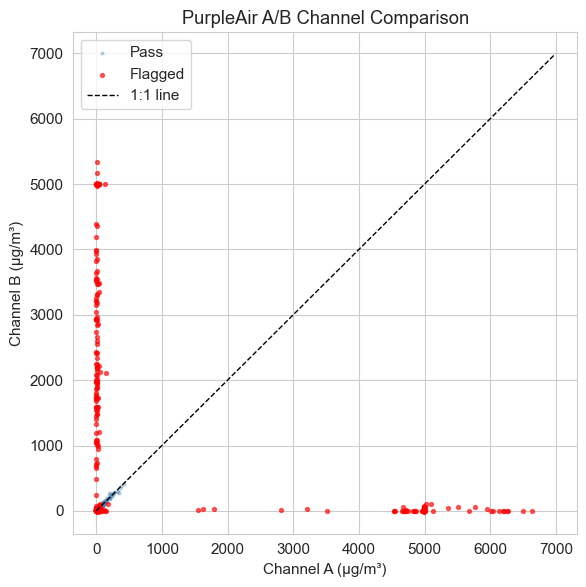

In [3]:
cleaner = DataCleaner()

# Flag A/B disagreements before dropping
pa_flagged = cleaner.flag_ab_channel_disagreement(pa_raw)
flag_pct = pa_flagged['ab_channel_flag'].mean() * 100
print(f"A/B flag rate: {flag_pct:.2f}% of all readings")

# Scatter plot: A vs B (colored by flag)
sample = pa_flagged.sample(min(5000, len(pa_flagged)), random_state=42)
fig, ax = plt.subplots(figsize=(6, 6))
ok   = sample[~sample['ab_channel_flag']]
bad  = sample[sample['ab_channel_flag']]
ax.scatter(ok['pm2.5_cf_1_a'],  ok['pm2.5_cf_1_b'],  s=4, alpha=0.3, color='steelblue', label='Pass')
ax.scatter(bad['pm2.5_cf_1_a'], bad['pm2.5_cf_1_b'],  s=8, alpha=0.6, color='red', label='Flagged')
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
ax.set_xlabel('Channel A (µg/m³)')
ax.set_ylabel('Channel B (µg/m³)')
ax.set_title('PurpleAir A/B Channel Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_ab_qc.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Apply LRAPA Correction

The LRAPA (Lane Regional Air Protection Agency) correction adjusts PurpleAir
CF=1 readings to better match regulatory-grade instruments:

**PM2.5_corrected = 0.5 × CF_1 - 0.66**

This formula was developed locally for Eugene/Lane County and validated against
LRAPA professional monitors, particularly during wildfire smoke events.

A/B QC: flagged 6298 records (7.2%) with channel disagreement
Dropped 6298 A/B-flagged records
Applied LRAPA correction to 'pm2.5_cf_1_a' → 'pm2.5_lrapa'
Removed 24641 records with invalid PM2.5 values


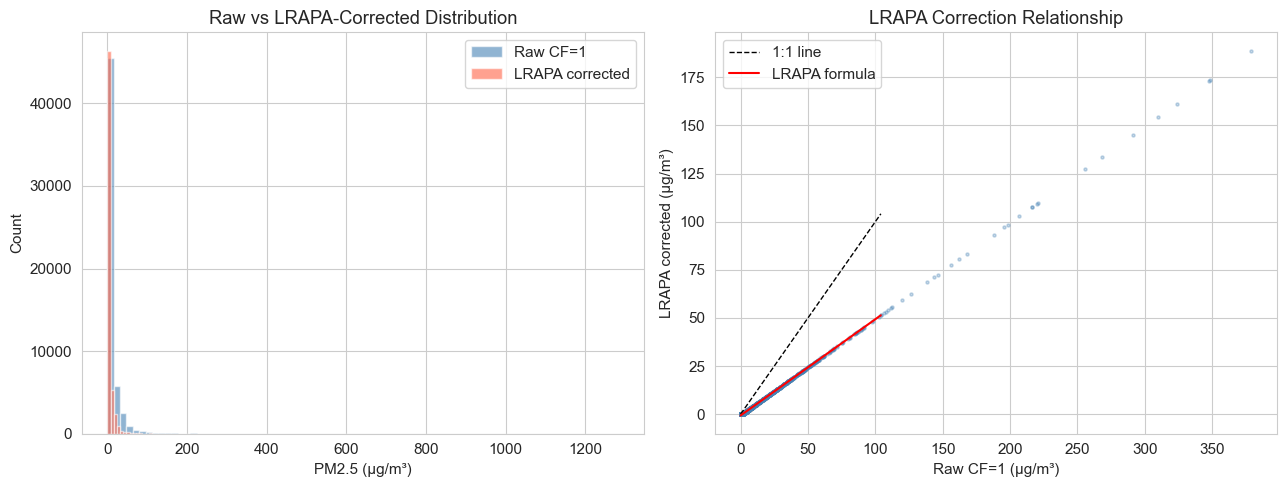


Mean raw:       11.91 µg/m³
Mean corrected: 5.39 µg/m³


In [4]:
# Full PurpleAir clean: A/B QC + LRAPA correction + range filter
pa_clean = cleaner.clean_purpleair_data(pa_raw, apply_lrapa=True, drop_ab_flagged=True)

# Show correction effect
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram comparison
ax = axes[0]
ax.hist(pa_clean['pm2.5_cf_1_a'].dropna(), bins=80, alpha=0.6, color='steelblue', label='Raw CF=1')
ax.hist(pa_clean['pm2.5_lrapa'].dropna(),   bins=80, alpha=0.6, color='tomato',    label='LRAPA corrected')
ax.set_xlabel('PM2.5 (µg/m³)')
ax.set_ylabel('Count')
ax.set_title('Raw vs LRAPA-Corrected Distribution')
ax.legend()

# Scatter: raw vs corrected (sample)
ax = axes[1]
s = pa_clean.sample(min(3000, len(pa_clean)), random_state=42)
ax.scatter(s['pm2.5_cf_1_a'], s['pm2.5_lrapa'], s=5, alpha=0.3, color='steelblue')
lim = s['pm2.5_cf_1_a'].quantile(0.99)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
# Draw the LRAPA correction line
x = np.linspace(0, lim, 100)
ax.plot(x, 0.5*x - 0.66, 'r-', linewidth=1.5, label='LRAPA formula')
ax.set_xlabel('Raw CF=1 (µg/m³)')
ax.set_ylabel('LRAPA corrected (µg/m³)')
ax.set_title('LRAPA Correction Relationship')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_lrapa_correction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMean raw:       {pa_clean['pm2.5_cf_1_a'].mean():.2f} µg/m³")
print(f"Mean corrected: {pa_clean['pm2.5_lrapa'].mean():.2f} µg/m³")

## 4. Validate PurpleAir Against LRAPA Regulatory Data

Compare the LRAPA-corrected PurpleAir median against LRAPA's professional instruments.
Strong agreement validates the correction approach and the sensor network's reliability.

Overlapping timestamps for validation: 1431

Pearson r:  0.899  (p = 0.00e+00)
RMSE:       4.97 µg/m³
Mean bias:  -1.31 µg/m³ (PA − regulatory)


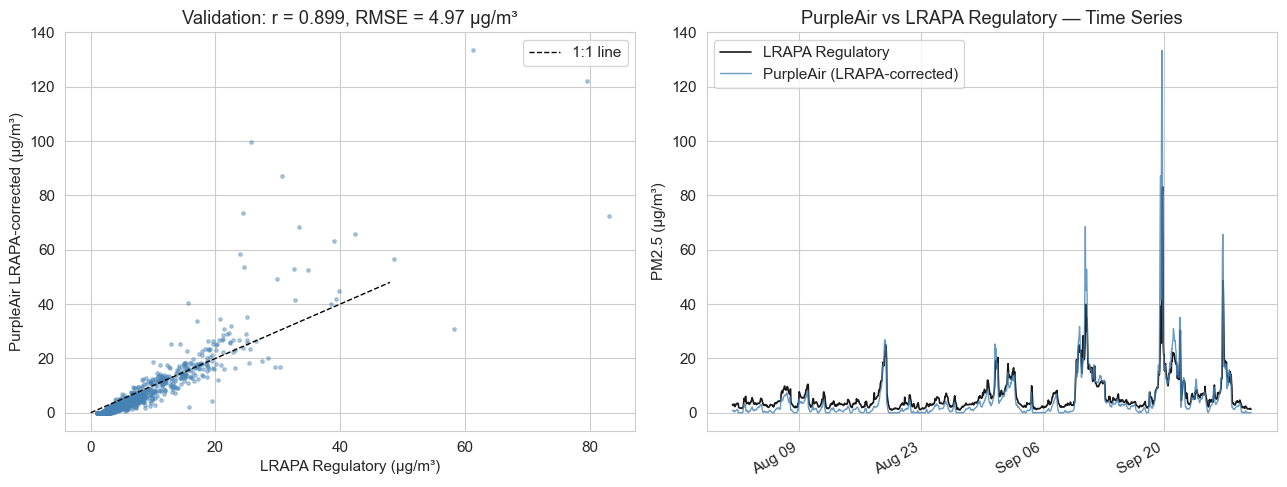

In [5]:
# Aggregate PA to hourly median for validation
pa_hourly_val = pa_clean.groupby('timestamp')['pm2.5_lrapa'].median().reset_index()
pa_hourly_val.columns = ['timestamp', 'pm2.5_pa_corrected']

# Merge with LRAPA regulatory on timestamp
val = pd.merge(pa_hourly_val, lrapa_raw[['timestamp','pm2.5_lrapa_regulatory']],
               on='timestamp', how='inner').dropna()
print(f"Overlapping timestamps for validation: {len(val)}")

r, p = stats.pearsonr(val['pm2.5_pa_corrected'], val['pm2.5_lrapa_regulatory'])
rmse = np.sqrt(((val['pm2.5_pa_corrected'] - val['pm2.5_lrapa_regulatory'])**2).mean())
bias = (val['pm2.5_pa_corrected'] - val['pm2.5_lrapa_regulatory']).mean()
print(f"\nPearson r:  {r:.3f}  (p = {p:.2e})")
print(f"RMSE:       {rmse:.2f} µg/m³")
print(f"Mean bias:  {bias:.2f} µg/m³ (PA − regulatory)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
lim = max(val['pm2.5_pa_corrected'].quantile(0.99), val['pm2.5_lrapa_regulatory'].quantile(0.99))
ax.scatter(val['pm2.5_lrapa_regulatory'], val['pm2.5_pa_corrected'],
           s=6, alpha=0.4, color='steelblue')
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
ax.set_xlabel('LRAPA Regulatory (µg/m³)')
ax.set_ylabel('PurpleAir LRAPA-corrected (µg/m³)')
ax.set_title(f'Validation: r = {r:.3f}, RMSE = {rmse:.2f} µg/m³')
ax.legend()

# Time series overlay
ax = axes[1]
ax.plot(val['timestamp'], val['pm2.5_lrapa_regulatory'], color='black', linewidth=1.2,
        label='LRAPA Regulatory', alpha=0.9)
ax.plot(val['timestamp'], val['pm2.5_pa_corrected'], color='steelblue', linewidth=1,
        label='PurpleAir (LRAPA-corrected)', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PurpleAir vs LRAPA Regulatory — Time Series')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_pa_vs_lrapa_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Build Final Analysis Dataset

In [6]:
df = create_full_analysis_dataset(
    purpleair_df=pa_raw,
    noaa_df=noaa_eug,
    lrapa_df=lrapa_raw,
    noaa_station=None,   # already filtered above
    add_features=True,
    remove_outliers=False
)
df.head(3)

=== Creating Full Analysis Dataset ===

1. Cleaning NOAA data...
Removed 1 duplicate timestamps

2. Cleaning PurpleAir data (A/B QC + LRAPA correction)...
A/B QC: flagged 6298 records (7.2%) with channel disagreement
Dropped 6298 A/B-flagged records
Applied LRAPA correction to 'pm2.5_cf_1_a' → 'pm2.5_lrapa'
Removed 24641 records with invalid PM2.5 values
Aggregated 49 sensors → 1440 hourly timestamps

3. Preparing LRAPA regulatory data...
   3288 LRAPA hourly records

4. Merging all three datasets on timestamp...
   Final dataset: 1440 records
   Date range:    2022-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00

5. Adding features...

Missing values:
snowdepth                        1440
temperature_f                       1
temperature_c                       1
dewpoint_f                          1
dewpoint_c                          1
humidity                            1
pressure_hpa                        1
wind_speed_knots                    1
wind_speed_mph                    

,timestamp,pm2.5_lrapa,pm2.5_lrapa_std,pm2.5_cf1_raw,pm2.5_cf1_raw_std,pm2.5_alt,pm2.5_alt_a_std,pm2.5_atm,pm2.5_atm_a_std,n_sensors,...,wind_speed_mph_lag_1h,wind_speed_mph_lag_3h,wind_speed_mph_lag_6h,wind_speed_mph_lag_12h,wind_speed_mph_lag_24h,pressure_hpa_lag_1h,pressure_hpa_lag_3h,pressure_hpa_lag_6h,pressure_hpa_lag_12h,pressure_hpa_lag_24h
0,2022-07-31 17:00:00-07:00,2.258857,1.202145,5.820000,2.440564,4.722857,1.609546,5.811429,2.427026,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07-31 18:00:00-07:00,2.062000,1.067415,5.405714,2.216906,4.380000,1.420812,5.405714,2.216906,35,...,9.20624,NaN,NaN,NaN,NaN,1011.3,NaN,NaN,NaN,NaN
2,2022-07-31 19:00:00-07:00,1.940286,0.967883,5.174286,1.995339,4.162857,1.254659,5.171429,1.993161,35,...,14.96014,NaN,NaN,NaN,NaN,1011.3,NaN,NaN,NaN,NaN


In [7]:
print("=== Final Dataset Summary ===")
print(f"Records:  {len(df):,}")
print(f"Columns:  {len(df.columns)}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nKey columns: {[c for c in df.columns if not c.endswith(('_std','_rolling','_lag'))]}")
print(f"\nDescriptive stats (PM2.5 + weather):")
key_cols = ['pm2.5_lrapa', 'pm2.5_cf1_raw', 'pm2.5_lrapa_regulatory',
            'temperature_f', 'humidity', 'wind_speed_mph', 'pressure_hpa']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(2)

=== Final Dataset Summary ===
Records:  1,440
Columns:  86
Date range: 2022-07-31 17:00:00-07:00 → 2022-09-29 16:00:00-07:00

Key columns: ['timestamp', 'pm2.5_lrapa', 'pm2.5_cf1_raw', 'pm2.5_alt', 'pm2.5_atm', 'n_sensors', 'snowdepth', 'temperature_f', 'temperature_c', 'dewpoint_f', 'dewpoint_c', 'humidity', 'pressure_hpa', 'wind_speed_knots', 'wind_speed_mph', 'wind_speed_mps', 'wind_direction', 'precipitation_in', 'precipitation_mm', 'visibility_miles', 'visibility_km', 'pm2.5_lrapa_regulatory', 'year', 'month', 'day', 'hour', 'dayofweek', 'dayofyear', 'week', 'season', 'is_weekend', 'wind_dir_sin', 'wind_dir_cos', 'pm2.5_lrapa_rolling_mean_3h', 'pm2.5_lrapa_rolling_std_3h', 'pm2.5_lrapa_rolling_mean_6h', 'pm2.5_lrapa_rolling_std_6h', 'pm2.5_lrapa_rolling_mean_12h', 'pm2.5_lrapa_rolling_std_12h', 'pm2.5_lrapa_rolling_mean_24h', 'pm2.5_lrapa_rolling_std_24h', 'temperature_f_rolling_mean_3h', 'temperature_f_rolling_std_3h', 'temperature_f_rolling_mean_6h', 'temperature_f_rolling_std_6

,pm2.5_lrapa,pm2.5_cf1_raw,pm2.5_lrapa_regulatory,temperature_f,humidity,wind_speed_mph,pressure_hpa
count,1440.00,1440.00,1431.00,1439.00,1439.00,1439.00,1439.00
mean,5.45,12.03,6.29,67.97,63.37,6.41,1015.36
std,10.34,20.77,6.71,11.05,20.52,4.57,3.62
min,0.00,0.09,0.95,45.00,15.98,0.00,1002.50
25%,0.68,2.40,2.81,60.00,45.90,3.45,1013.40
50%,1.89,5.05,3.86,66.00,66.72,5.75,1015.40
75%,5.31,11.93,7.12,76.00,80.75,9.21,1017.90
max,125.10,251.53,83.18,99.00,98.90,23.02,1023.70


In [8]:
# Label each row by fire event based on year
event_map = {2020: 'Holiday Farm Fire 2020', 2022: 'Cedar Creek Fire 2022'}
df['event'] = df['timestamp'].dt.year.map(event_map).fillna('other')
print('Event breakdown:')
print(df['event'].value_counts().to_string())
print()

df.to_csv("../data/processed/analysis_data.csv", index=False)
print(f"Saved {len(df):,} records to data/processed/analysis_data.csv")

Event breakdown:
event
Cedar Creek Fire 2022    1440

Saved 1,440 records to data/processed/analysis_data.csv
